### Dataset Link: [Bank Marketing](https://drive.google.com/file/d/1hU1vxwbRpQ8ahj-ewUjbv3eqwhe2Q6gB/view)

## Theoretical Questions

### Q1. What is a Decision Tree? Explain its structure (Root, Nodes, Leaves) with a real-life example.

### Solution
A **Decision Tree** is a supervised machine-learning algorithm used for classification and regression. It makes predictions by repeatedly splitting data according to feature values and forming a tree-like structure.

The main components are:

- Root Node: The first and most important decision/split in the tree.
- Internal Nodes: Intermediate decision points where the data is further divided.
- Branches: Represent the outcome of a decision.
- Leaf Nodes: Final nodes containing the predicted class or value.

Real-life example:

Suppose a bank wants to predict whether a customer will subscribe to a term deposit.

A simplified tree could work as follows:

                 Duration
              /           \
          Short             Long
          /                   \
     Housing=Yes          Poutcome=Success
       /       \             /        \
      No       Yes          Yes        No
      |         |            |          |
     No        No           Yes         No

  The tree makes a prediction by following the appropriate branch from the root to a leaf.

### Q2. Differentiate between Gini impurity and Entropy. Which one is used by default in Scikit-learn and why?

### Solution
|Gini Impurity	|Entropy|
| --- | --- |
|Measures the probability of incorrectly classifying a randomly selected sample	|Measures the uncertainty or disorder in the data|
|Formula: 1 - Σpᵢ²	|Formula: -Σpᵢ log₂(pᵢ)|
|Generally computationally faster	|Requires logarithmic calculations|
|Lower Gini means purer node	|Lower entropy means purer node|
|Commonly used for classification trees	|Also commonly used for classification trees|

Scikit-learn default:

For DecisionTreeClassifier, the default criterion is gini. Gini is commonly used because it provides an efficient measure of node impurity without requiring logarithmic calculations.

### Q3. What is Overfitting in Decision Trees? How can we detect it using training and testing accuracy?

### Solution
**Overfitting** occurs when a Decision Tree learns the training data too closely, including noise and random patterns, instead of learning patterns that generalize to unseen data.

A common indication is:
```
Training accuracy  → Very high
Testing accuracy   → Much lower
```
For example:
```
Training Accuracy = 95%
Testing Accuracy  = 75%
```
This large difference suggests overfitting.

If training and testing accuracy are both low, the model may instead be **underfitting**.

### Q4. Explain Pruning in Decision Trees. What is the difference between Pre-pruning and Post-pruning?

### Solution
**Pruning** is the process of limiting or reducing the complexity of a Decision Tree to improve generalization.

**Pre-pruning**

Pre-pruning limits tree growth while the tree is being constructed.

Examples:
```
max_depth=3
min_samples_split=20
```
**Post-pruning**

Post-pruning first allows a larger tree to grow and then removes unnecessary branches.

|Pre-pruning	|Post-pruning|
| ---- | ---- |
|Stops tree growth early	|Removes branches after tree construction|
|Applied during training|	Applied after/while evaluating the fully grown tree|
|Uses constraints such as `max_depth`	|Can use cost-complexity pruning|

### Q5. What is Feature Importance? How can it help businesses in decision-making?

### Solution
**Feature importance** indicates how much each feature contributes to the decisions made by a machine-learning model.

In a Decision Tree, important features are those that contribute substantially to reducing impurity during tree splitting.

Feature importance can help a bank:

- Identify customer characteristics associated with successful campaigns.
- Understand which variables are useful for prediction.
- Prioritize customer segments.
- Improve marketing strategies.
- Potentially reduce unnecessary marketing efforts.

Feature importance shows association/predictive contribution, not causation.

## Practical Questions

### Q6. Data Understanding
- Load the dataset
- Display first 5 rows
- Check:
  - Shape
  - Data types
  - Column names

**Interpret**
- What types of variables are present?

In [3]:
# Solution

# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading dataset
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('bank.csv')

# Displaying first 5 rows
print("First 5 rows of the dataset are:")
display(df.head())

# Getting information about shape of dataset
print("\nShape of the dataset is: ", df.shape)

# Getting information about data types
print("\nData types of the dataset are:")
print(df.dtypes)

# Getting information about column names
print("\nColumn names of the dataset are:")
print(df.columns)

Saving bank.csv to bank (2).csv
First 5 rows of the dataset are:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes



Shape of the dataset is:  (11162, 17)

Data types of the dataset are:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object

Column names of the dataset are:
Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')


There are two types of variables in the dataset:

1. Numerical variables
```
[age,balance,day,duration,campaign,pdays,previous]
```
2. Categorical variables
```
[job,marital,education,default,housing,loan,contact,month,poutcome,deposit]
```

The target variable is `deposit` it contains:
- yes
- no

### Q7. Data Cleaning
- Check for missing values
- Handle missing values (if any)
- Check for duplicates

**Interpret**
- Is the dataset clean? What issues did you find?

In [4]:
# Solution

# Check missing values
print("Missing values:")
print(df.isnull().sum())

# Total missing values
print("\nTotal missing values:")
print(df.isnull().sum().sum())

# Check duplicates
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

Missing values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

Total missing values:
0

Number of duplicate rows:
0


**Interpretation**

The dataset is clean with respect to:

- Missing values
- Duplicate rows

Therefore, no missing-value imputation is required.

The categorical values such as `unknown` are actual category values in the dataset; they are not the same thing as pandas `NaN` missing values.

### Q8. Data Preprocessing
- Convert categorical variables into numerical
- Mention which encoding method you used

**Interpret**
- Why is encoding necessary for Decision Trees?

In [5]:
# Solution

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Separate features and target
X = df.drop('deposit', axis=1)
y = df['deposit']

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

# One-hot encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('categorical',
         OneHotEncoder(handle_unknown='ignore'),
         categorical_cols)
    ],
    remainder='passthrough'
)

print("\nOne-Hot Encoding will be applied to categorical variables.")

Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Numerical columns:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

One-Hot Encoding will be applied to categorical variables.


**Interpretation**

Encoding is necessary because machine-learning algorithms require numerical representations of input variables.

One-Hot Encoding is appropriate for nominal categorical variables because it does not incorrectly imply an ordering between categories.

### Q9. Feature Selection & Splitting
- Separate:
  - Feature (X)
  - Feature (Y)
- Perform train-test split (80-20)

**Interpret**
- Why is train-test split important?

In [6]:
# Solution

from sklearn.model_selection import train_test_split

# Features
X = df.drop('deposit', axis=1)

# Target
y = df['deposit']

# 80-20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data shape: (8929, 16)
Testing data shape: (2233, 16)

Training target distribution:
deposit
no     4698
yes    4231
Name: count, dtype: int64

Testing target distribution:
deposit
no     1175
yes    1058
Name: count, dtype: int64


**Interpretation**

The dataset is divided into:
```
80% → Training data
20% → Testing data
```
The training data is used to build the model, while the testing data evaluates its performance on previously unseen observations.

The `stratify=y` argument maintains approximately the same target-class distribution in both datasets.

**Why is train-test split important?**

Without a separate test set, we cannot properly determine whether the model generalizes to unseen data.

### Q10. Model Building
- Train a Decision Tree Classifier
- Use:
  - criterion = 'gini'
  - max_depth = 5

**Interpret**
- What does max_depth control?

In [7]:
# Solution

from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

# Decision Tree model
dt_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        criterion='gini',
        max_depth=5,
        random_state=42
    ))
])

# Train model
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


**What does `max_depth` control?**

`max_depth` controls the maximum number of levels in the Decision Tree.

Here:
```
max_depth=5
```
means the tree can grow to a maximum depth of 5.

A smaller depth generally makes the tree simpler, while a very large depth can increase the risk of overfitting.

### Q11. Model Evaluation
Perform:
- Accuracy score
- Confusion Matrix
- Classification Report

**Interpret**
- Is the model performing well?
- Explain Precision & Recall
- Any class imbalance issue?

In [8]:
# Solution

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Predictions
y_pred = dt_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8034034930586654

Confusion Matrix:
[[946 229]
 [210 848]]

Classification Report:
              precision    recall  f1-score   support

          no       0.82      0.81      0.81      1175
         yes       0.79      0.80      0.79      1058

    accuracy                           0.80      2233
   macro avg       0.80      0.80      0.80      2233
weighted avg       0.80      0.80      0.80      2233



**Result with `random_state=42`**

The test accuracy is approximately:
```
Accuracy = 0.8034
```
or:
```
80.34%
```
The confusion matrix is:
```
[[946 229]
 [210 848]]
```
Using the class order:
```
['no', 'yes']
```
this means:

|Actual / Predicted|	No|	Yes|
| --- | --- | --- |
|No	|946	|229|
|Yes|	210|	848|

The classification report is approximately:

|Class	|Precision	|Recall	|F1-score|
| --- | --- | --- | --- |
|no|	0.82|	0.81|	0.81|
|yes|	0.79|	0.80|	0.79|

**Precision**

For a particular class, precision tells us how many observations predicted as that class were actually that class.

For the `yes` class:
```
Precision ≈ 0.79
```
So approximately 79% of customers predicted as yes were actually yes in this test set.

**Recall**

Recall measures how many actual members of a class were correctly identified.

For the `yes` class:
```
Recall ≈ 0.80
```
So the model identified approximately 80% of the actual yes cases.

**Is the model performing well?**

The model achieves approximately 80.34% test accuracy, with precision and recall around 0.8 for both classes. This indicates that the model is making reasonably consistent predictions on this particular train-test split.

However, accuracy alone should not be used as the only measure of performance.

**Class imbalance**

The target distribution is:
```
no  = 5,873
yes = 5,289
```
Percentages:
```
no  ≈ 52.62%
yes ≈ 47.38%
```
Therefore, the dataset is not severely imbalanced. The two classes are relatively close in size.

### Q12. Overfitting Check
- Calculate:
  - Training accuracy
  - Testing accuracy

**Interpret**
- Is the model overfitting or underfitting?

In [9]:
# Solution

# Training predictions
train_pred = dt_model.predict(X_train)

# Testing predictions
test_pred = dt_model.predict(X_test)

# Accuracy
train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

print("\nAccuracy Difference:",
      train_accuracy - test_accuracy)

Training Accuracy: 0.8077052301489529
Testing Accuracy: 0.8034034930586654

Accuracy Difference: 0.004301737090287472


**Interpretation**

The training and testing accuracies are very close.

Therefore, for this `max_depth=5` model:

- There is no strong indication of overfitting.
- There is also no obvious severe underfitting based solely on these accuracy values.
- The small train-test accuracy difference indicates reasonably similar performance on training and unseen test data.

### Q13. Pruning Experiment
- Train another model with:
  - max_depth = 3
  - min_samples_split = 20

**Interpret**
- Compare performance with previous model
- Which one is better and why?

In [10]:
# Solution

# Pruned / restricted Decision Tree
pruned_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        criterion='gini',
        max_depth=3,
        min_samples_split=20,
        random_state=42
    ))
])

# Train
pruned_model.fit(X_train, y_train)

# Predictions
pruned_train_pred = pruned_model.predict(X_train)
pruned_test_pred = pruned_model.predict(X_test)

# Accuracy
pruned_train_accuracy = accuracy_score(
    y_train,
    pruned_train_pred
)

pruned_test_accuracy = accuracy_score(
    y_test,
    pruned_test_pred
)

print("Pruned Tree Training Accuracy:",
      pruned_train_accuracy)

print("Pruned Tree Testing Accuracy:",
      pruned_test_accuracy)

Pruned Tree Training Accuracy: 0.7785866278418636
Pruned Tree Testing Accuracy: 0.7801164352888491


**Results**

Approximately:

|Model	|Training Accuracy|	Testing Accuracy|
| --- | --- | --- |
|Original (`max_depth=5`)	|80.77%	|80.34%|
|Restricted (`max_depth=3`, `min_samples_split=20`)	|77.86%	|78.01%|

**Interpretation**

The restricted tree has lower testing accuracy on this particular split:
```
Max depth 5     → 80.34%
Max depth 3     → 78.01%
```
The `max_depth=5` model therefore has higher measured test accuracy for this experiment.

However, the two models have different complexity levels and error profiles. Model selection should consider the business objective and metrics beyond accuracy.

For example, the restricted model has higher recall for the `yes` class in this split, while the depth-5 model has higher overall accuracy.

### Q14. Feature Importance
- Extract top 5 important features
- plot feature importance graph

**Interpret**
- Which features influence prediction the most?

Top 5 Important Features:


,Feature,Importance
47,duration,0.606230
42,poutcome_success,0.159335
27,contact_unknown,0.141635
22,housing_yes,0.036343
35,month_mar,0.032731


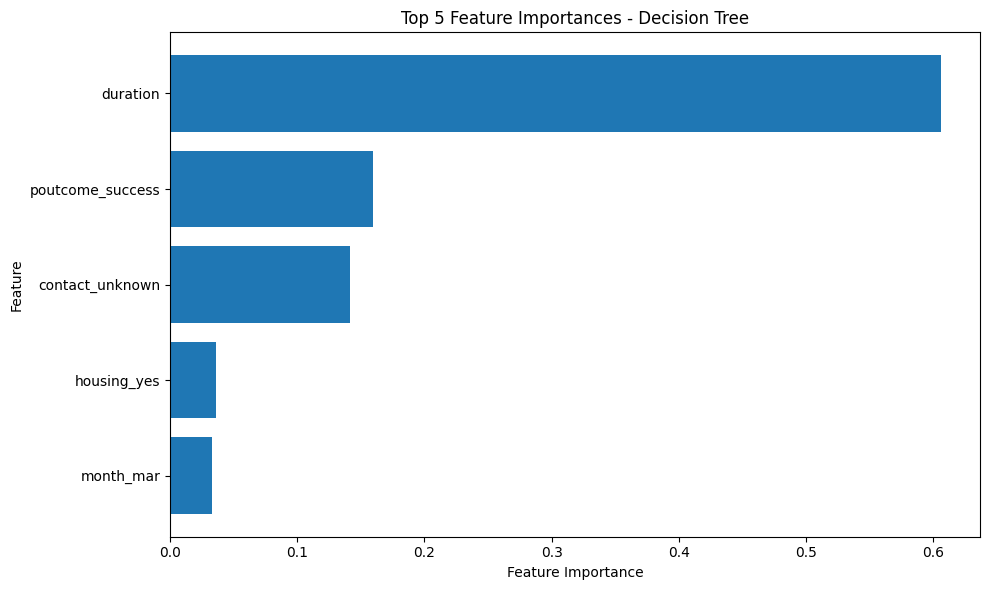

In [11]:
# Solution

# Get trained Decision Tree
tree = dt_model.named_steps['classifier']

# Get preprocessing transformer
encoder = dt_model.named_steps['preprocessor']

# Get encoded categorical feature names
encoded_cat_features = (
    encoder
    .named_transformers_['categorical']
    .get_feature_names_out(categorical_cols)
)

# Combine with numerical feature names
feature_names = list(encoded_cat_features) + numerical_cols

# Feature importance
importance = tree.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

# Sort
feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Top 5
top_5 = feature_importance_df.head(5)

print("Top 5 Important Features:")
display(top_5)

# Plot
plt.figure(figsize=(10, 6))

plt.barh(
    top_5['Feature'][::-1],
    top_5['Importance'][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 5 Feature Importances - Decision Tree")
plt.tight_layout()
plt.show()

**Interpretation**

The Decision Tree gives the largest importance to:
```
duration
```
followed by:
```
poutcome_success
contact_unknown
housing_yes
month_mar
```
This means these encoded variables contributed substantially to the tree's impurity reduction for this fitted model.

Important business caveat: `duration` represents the duration of the current contact. If the bank wants to decide before making the call, duration would not be known beforehand. Therefore, a model intended for pre-contact targeting should consider removing `duration` and retraining the model.

Feature importance should also not be interpreted as proof that changing a feature will cause the target outcome to change.

### Q15. Business Insights
Based on your model Answer:
- Which type of customers are more likely to say "yes"?
- What Strategy should a bank use

### Solution part 1

Looking at the dataset's observed subscription rates:

**Previous campaign outcome**

Customers with:
```
poutcome = success
```
have a particularly high observed `yes` rate:
```
≈ 91.32%
```
Compared with:
```
poutcome = unknown → ≈ 40.67%
poutcome = failure → ≈ 50.33%
poutcome = other   → ≈ 57.17%
```

**Contact method**

Customers contacted through:
```
cellular → ≈ 54.33% yes
telephone → ≈ 50.39% yes
unknown → ≈ 22.59% yes
```
**Housing loan**

Customers with:
```
housing = no → ≈ 57.03% yes
housing = yes → ≈ 36.64% yes
```
**Job**

Some observed customer segments also have relatively high subscription rates, for example:
```
student  → ≈ 74.72%
retired  → ≈ 66.32%
unemployed → ≈ 56.58%
```
These are observed associations in this dataset, not causal effects.

### Solution part 2

Based on the model and observed data, a bank could:

1. Prioritize customers with a successful previous campaign outcome, since this group has a high observed subscription rate.
2. Use the model to identify customers with a higher predicted probability of subscribing.
3. Consider customer characteristics such as contact method, housing status, previous campaign outcome, and other available features.
4. Avoid treating model predictions as guaranteed outcomes.
5. Evaluate campaign performance continuously using appropriate metrics.
6. For campaigns planned before contacting customers, exclude variables that are only known after or during the contact, such as `duration`.

A practical workflow would therefore be:
```
Customer Data
      ↓
Data Cleaning
      ↓
Feature Encoding
      ↓
Decision Tree
      ↓
Customer Prediction
      ↓
Identify Higher-Probability Segments
      ↓
Targeted Marketing
      ↓
Measure Campaign Results
```